In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import *

### Load Data

In [ ]:
from huggingface_hub import login
# login(token="")  # Replace with your actual token

In [4]:
# Import datasets from
# lmarena-ai/VisionArena-Battle
# https://huggingface.co/datasets/lmsys
from datasets import load_dataset
ds = load_dataset("lmarena-ai/VisionArena-Battle")

In [5]:
# inspect the available splits
print(ds)  
# grab the test split
train = ds["train"]

DatasetDict({
    train: Dataset({
        features: ['images', 'question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'num_turns', 'language', 'tstamp', 'conv_metadata', 'categories'],
        num_rows: 29849
    })
})


In [6]:
df = train.to_pandas()
df.shape

(29849, 13)

In [ ]:
df.head()

In [8]:
# create a column winner_model_a, which is 1 if model_a is preferred, 0 if model_b is preferred
df['winner_model_a'] = df['winner'].apply(lambda x: 1 if x == 'model_a' else 0)
# create a column called winner_tie that is 1 if the winner is 'tie', else 0
df['winner_tie'] = df['winner'].apply(lambda x: 1 if x == 'tie' else 0)
df.head()

,images,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,num_turns,language,tstamp,conv_metadata,categories,winner_model_a,winner_tie
0,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,94f6f6508b6946db809cc700fbf57eb3,claude-3-opus-20240229,gpt-4o-2024-05-13,model_b,arena_user_WnxPidjDzH2jGCBPPDvbfm,"[[{'content': 'describe this cartoon', 'role':...","[[{'content': 'describe this cartoon', 'role':...",1,English,1.721366e+09,"{'context_a_tokens': 3, 'context_b_tokens': 3,...","{'captioning': True, 'creative_writing': False...",0,0
1,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,e7ef1e9839b746699f066ad1f255ad75,gemini-1.5-pro-exp-0801,claude-3-5-sonnet-20240620,model_b,arena_user_eKUpfCPzV2vdxp5TKsnNxe,[[{'content': 'Generate a list of relevant que...,[[{'content': 'Generate a list of relevant que...,1,English,1.721725e+09,"{'context_a_tokens': 11, 'context_b_tokens': 1...","{'captioning': False, 'creative_writing': Fals...",0,0
2,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,29a843b27c614391a6732e6c042fd5e0,gemini-1.5-flash-api-0514,claude-3-5-sonnet-20240620,model_b,arena_user_juLTzBXrDyBdSEunwWztg9,[[{'content': 'What bug died in my garden? Tho...,[[{'content': 'What bug died in my garden? Tho...,1,English,1.719587e+09,"{'context_a_tokens': 15, 'context_b_tokens': 1...","{'captioning': False, 'creative_writing': Fals...",0,0
3,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,274643b7fe2545c5bf32c7d5931d1553,reka-core-20240501,reka-flash-preview-20240611,tie,arena_user_Vb4wt4yAppRPwcAqukiU2N,[[{'content': 'Was versucht dieses Bild auszud...,[[{'content': 'Was versucht dieses Bild auszud...,1,German,1.719740e+09,"{'context_a_tokens': 45, 'context_b_tokens': 4...","{'captioning': False, 'creative_writing': Fals...",0,1
4,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,6ff0af95d14b411ca63f7ac5a281a9a1,claude-3-sonnet-20240229,llava-v1.6-34b,model_a,arena_user_FerRcceDpgBNiJyEmZCZWF,[[{'content': 'What can you say about this cha...,[[{'content': 'What can you say about this cha...,1,English,1.719235e+09,"{'context_a_tokens': 8, 'context_b_tokens': 8,...","{'captioning': False, 'creative_writing': Fals...",1,0


In [9]:
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")
# note, the proportion of ties is 9.17% for the LLM-as-judge data and 23.25% for the human-as-judge data.

Number of ties: 5216
Proportion of ties: 17.47%


In [10]:
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]
rawBT.head()
rawBT.shape
# rawBT_noTies.head() # (2575, 3)
# rawBT_noTies.shape

(29849, 4)

In [11]:
# how to get the unique names in both columns
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
# combine the two arrays and get the unique names
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))
# print the number of unique model names
print(f"Number of unique model names: {len(model_names)}")

Number of unique model names: 17


In [12]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

claude-3-5-sonnet-20240620: 6774
claude-3-haiku-20240307: 4284
claude-3-opus-20240229: 4184
claude-3-sonnet-20240229: 4222
cogvlm2-llama3-chat-19b: 896
gemini-1.5-flash-api-0514: 4098
gemini-1.5-pro-api-0514: 5012
gemini-1.5-pro-exp-0801: 4466
gpt-4-turbo-2024-04-09: 4111
gpt-4o-2024-05-13: 5281
gpt-4o-mini-2024-07-18: 4322
internvl2-26b: 1624
llava-v1.6-34b: 1823
minicpm-v-2_6: 797
phi-3-vision-128k-instruct: 654
reka-core-20240501: 3656
reka-flash-preview-20240611: 3494


In [13]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape

((59698, 16), (59698,))

## Uniform Data-dropping

In [15]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

original top 5 models:  {'gemini-1.5-pro-exp-0801': 0.7820840847198542, 'gpt-4o-2024-05-13': 0.7587497443356462, 'claude-3-5-sonnet-20240620': 0.6563404577446826, 'gemini-1.5-pro-api-0514': 0.4542761427657591, 'gpt-4-turbo-2024-04-09': 0.4161531705472802}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


#### Run Top-k Robustness Check.

In [ ]:
ks = [1]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = True)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
        alphaN += 1

In [ ]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 28): (0,
  11,
  0.023334340384208008,
  -0.0006314300443447385,
  array([22176,  9686,   887, 15782, 24340, 25110,  9816, 10926, 18732,
         21303, 13957,  2934,  2936, 19600, 11072, 15311, 11038, 25845,
         17732, 29100,  5421, 24462, 23006, 10572,  2134, 13518,  5390,
         15353])),
 (5, 146): (9,
  10,
  0.1306380880969069,
  -0.0005216049215385765,
  array([22247, 24488, 20679, 17733, 19425, 12194, 20545, 12773, 25762,
         16123,  4031,  2924, 21999,    69,  5364,  2210,  9946, 20462,
          1752, 18753,  8754,  5484, 27922, 27143, 15206, 16996, 19408,
         12057, 29754,  8859, 23571,   129, 27086, 23968,  7250,  1776,
         18920, 14644, 17364, 26346, 18468, 10752, 28190, 11310, 14887,
          2402,  9033, 28730, 25216, 18609,  3939, 25071, 15418,  7171,
         27241, 18808, 22043, 26447, 25586, 12258, 15487, 15265, 24023,
          8487, 27763, 14038, 11822,  7831,  9104, 16939, 24093, 29150,
         22542, 13634,  7914,  5750,  4152, 28515,

In [ ]:
28 / 29849

0.0009380548762102583

In [ ]:
# save results as a .pkl file.
# import pickle
# with open('results/visionNonrobustWtd.pkl', 'wb') as f:
#     pickle.dump(results_nonrobust, f)

In [ ]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

claude-3-5-sonnet-20240620: 6774
claude-3-haiku-20240307: 4284
claude-3-opus-20240229: 4184
claude-3-sonnet-20240229: 4222
cogvlm2-llama3-chat-19b: 896
gemini-1.5-flash-api-0514: 4098
gemini-1.5-pro-api-0514: 5012
gemini-1.5-pro-exp-0801: 4466
gpt-4-turbo-2024-04-09: 4111
gpt-4o-2024-05-13: 5281
gpt-4o-mini-2024-07-18: 4322
internvl2-26b: 1624
llava-v1.6-34b: 1823
minicpm-v-2_6: 797
phi-3-vision-128k-instruct: 654
reka-core-20240501: 3656
reka-flash-preview-20240611: 3494


In [ ]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 28, player_to_id)

In [ ]:
# plot the rankings on the original arena
filename_to_save = 'fig/top10_vision.png'
plot_title = 'Model Rankings in Vision Arena'
plot_bt_scores(X, y, rankings, alphaN, 10, plot_title, filename_to_save)

In [ ]:
results_nonrobust

{(1, 18): (11,
  None,
  -2.6720424681191832,
  0.1837221334672124,
  array([ 7164,  7539,  9112,  7711,  2089,  1815,  2414,  6542,  6446,
          4883,  8753,  2889,  9272,  3553,  1512,  5933,  6992, 10387])),
 (5, 13): (3,
  11,
  1.2819651846202045,
  -0.12369178206385278,
  array([7164, 7539, 9112, 7711, 1815, 2089, 2414, 6542, 6446, 4883, 8753,
         2889, 9272]))}

### Confidence Intervals

In [17]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [18]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(df, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:05<00:00, 16.85it/s]


In [19]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
model_a,,,
gemini-1.5-pro-exp-0801,1134.171964,1142.940861,1150.163642
gpt-4o-2024-05-13,1128.461120,1134.817986,1141.558463
claude-3-5-sonnet-20240620,1112.911426,1118.480748,1124.599466
gemini-1.5-pro-api-0514,1079.150252,1086.649062,1092.943712
gpt-4-turbo-2024-04-09,1071.951642,1081.064239,1089.073503
gpt-4o-mini-2024-07-18,1045.985158,1054.270536,1063.168123
gemini-1.5-flash-api-0514,1008.627446,1017.460662,1025.153336
claude-3-opus-20240229,996.610942,1006.313753,1012.978347
internvl2-26b,975.735713,988.057699,1001.489828


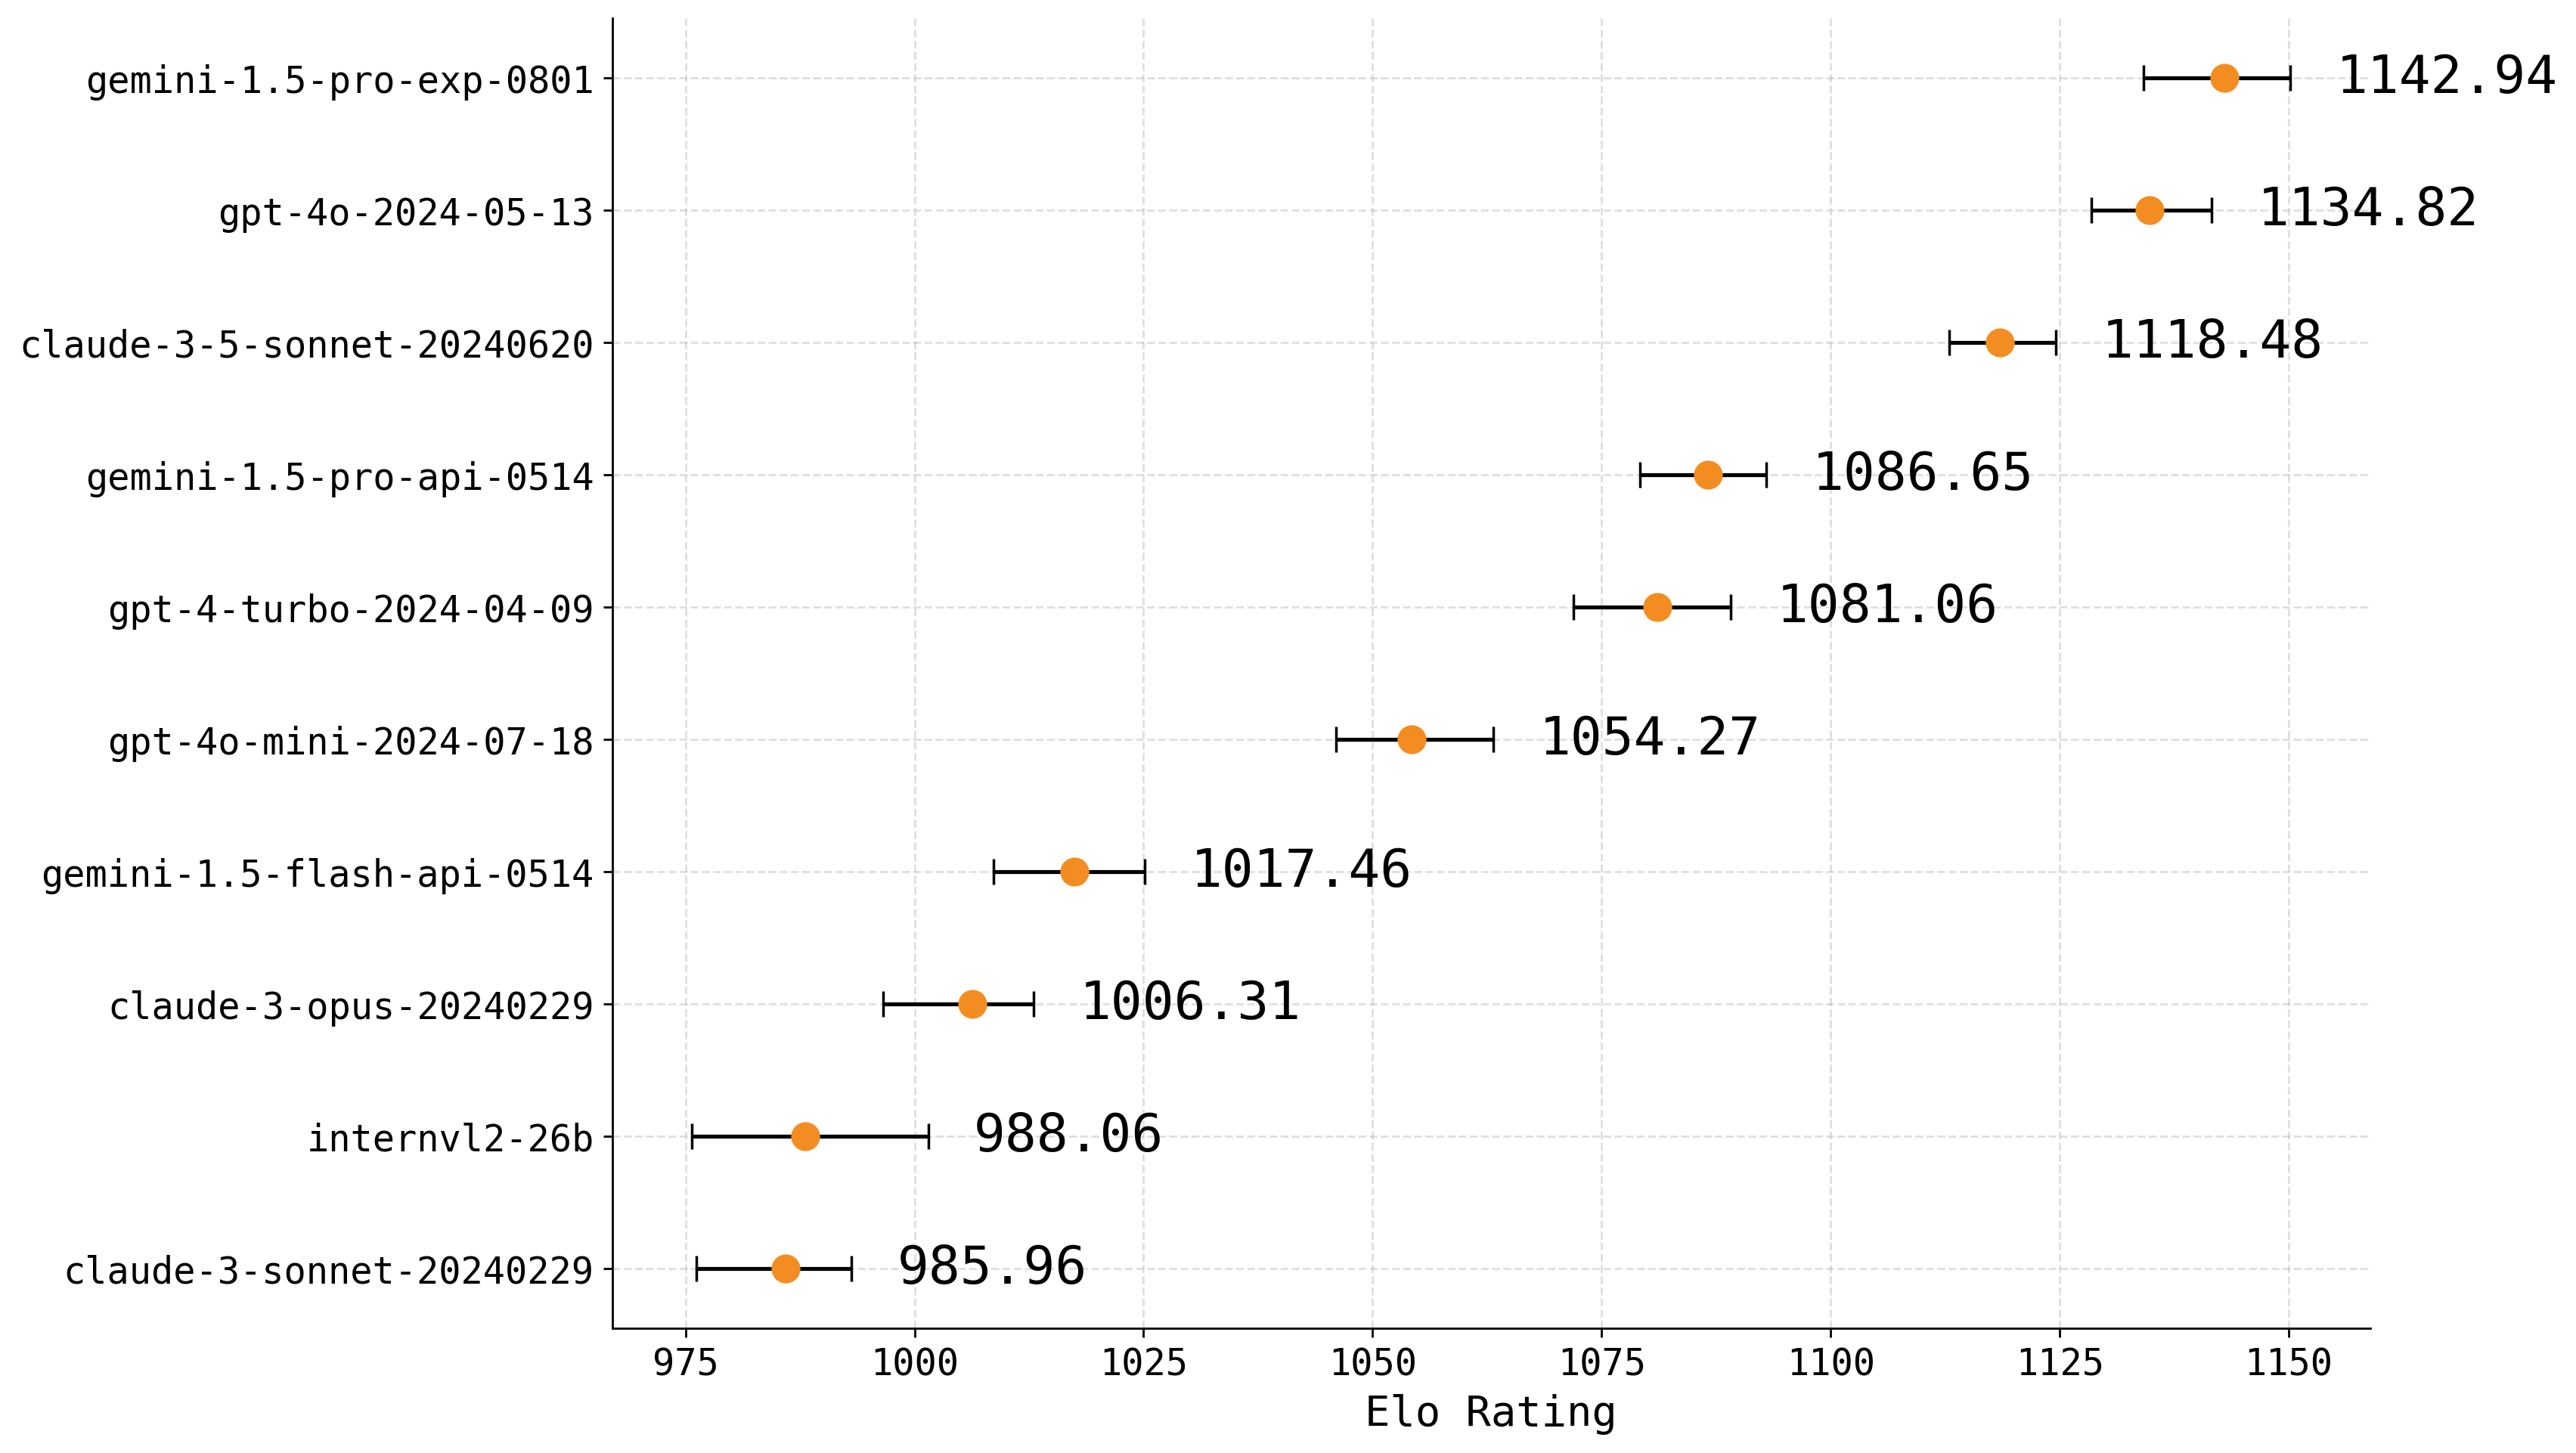

In [20]:
# plot the top 10 models.
compute_CIs.plot_elo_confidence_intervals(ci_df.head(10))

In [21]:
import pickle
with open('results/visionNonrobustWtd.pkl', 'rb') as f:
    results_nonrobust_loaded = pickle.load(f)

In [22]:
results_nonrobust_loaded

{(1, 28): (0,
  11,
  0.023334340384208008,
  -0.0006314300443447385,
  array([22176,  9686,   887, 15782, 24340, 25110,  9816, 10926, 18732,
         21303, 13957,  2934,  2936, 19600, 11072, 15311, 11038, 25845,
         17732, 29100,  5421, 24462, 23006, 10572,  2134, 13518,  5390,
         15353])),
 (5, 146): (9,
  10,
  0.1306380880969069,
  -0.0005216049215385765,
  array([22247, 24488, 20679, 17733, 19425, 12194, 20545, 12773, 25762,
         16123,  4031,  2924, 21999,    69,  5364,  2210,  9946, 20462,
          1752, 18753,  8754,  5484, 27922, 27143, 15206, 16996, 19408,
         12057, 29754,  8859, 23571,   129, 27086, 23968,  7250,  1776,
         18920, 14644, 17364, 26346, 18468, 10752, 28190, 11310, 14887,
          2402,  9033, 28730, 25216, 18609,  3939, 25071, 15418,  7171,
         27241, 18808, 22043, 26447, 25586, 12258, 15487, 15265, 24023,
          8487, 27763, 14038, 11822,  7831,  9104, 16939, 24093, 29150,
         22542, 13634,  7914,  5750,  4152, 28515,

In [26]:
top_1_mis = results_nonrobust_loaded[(1, 28)][4]
top_5_mis = results_nonrobust_loaded[(5, 146)][4]

### Robustness of Bootstrap Confidence Interval Rankings

In [37]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [38]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(df, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:05<00:00, 19.22it/s]


In [ ]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

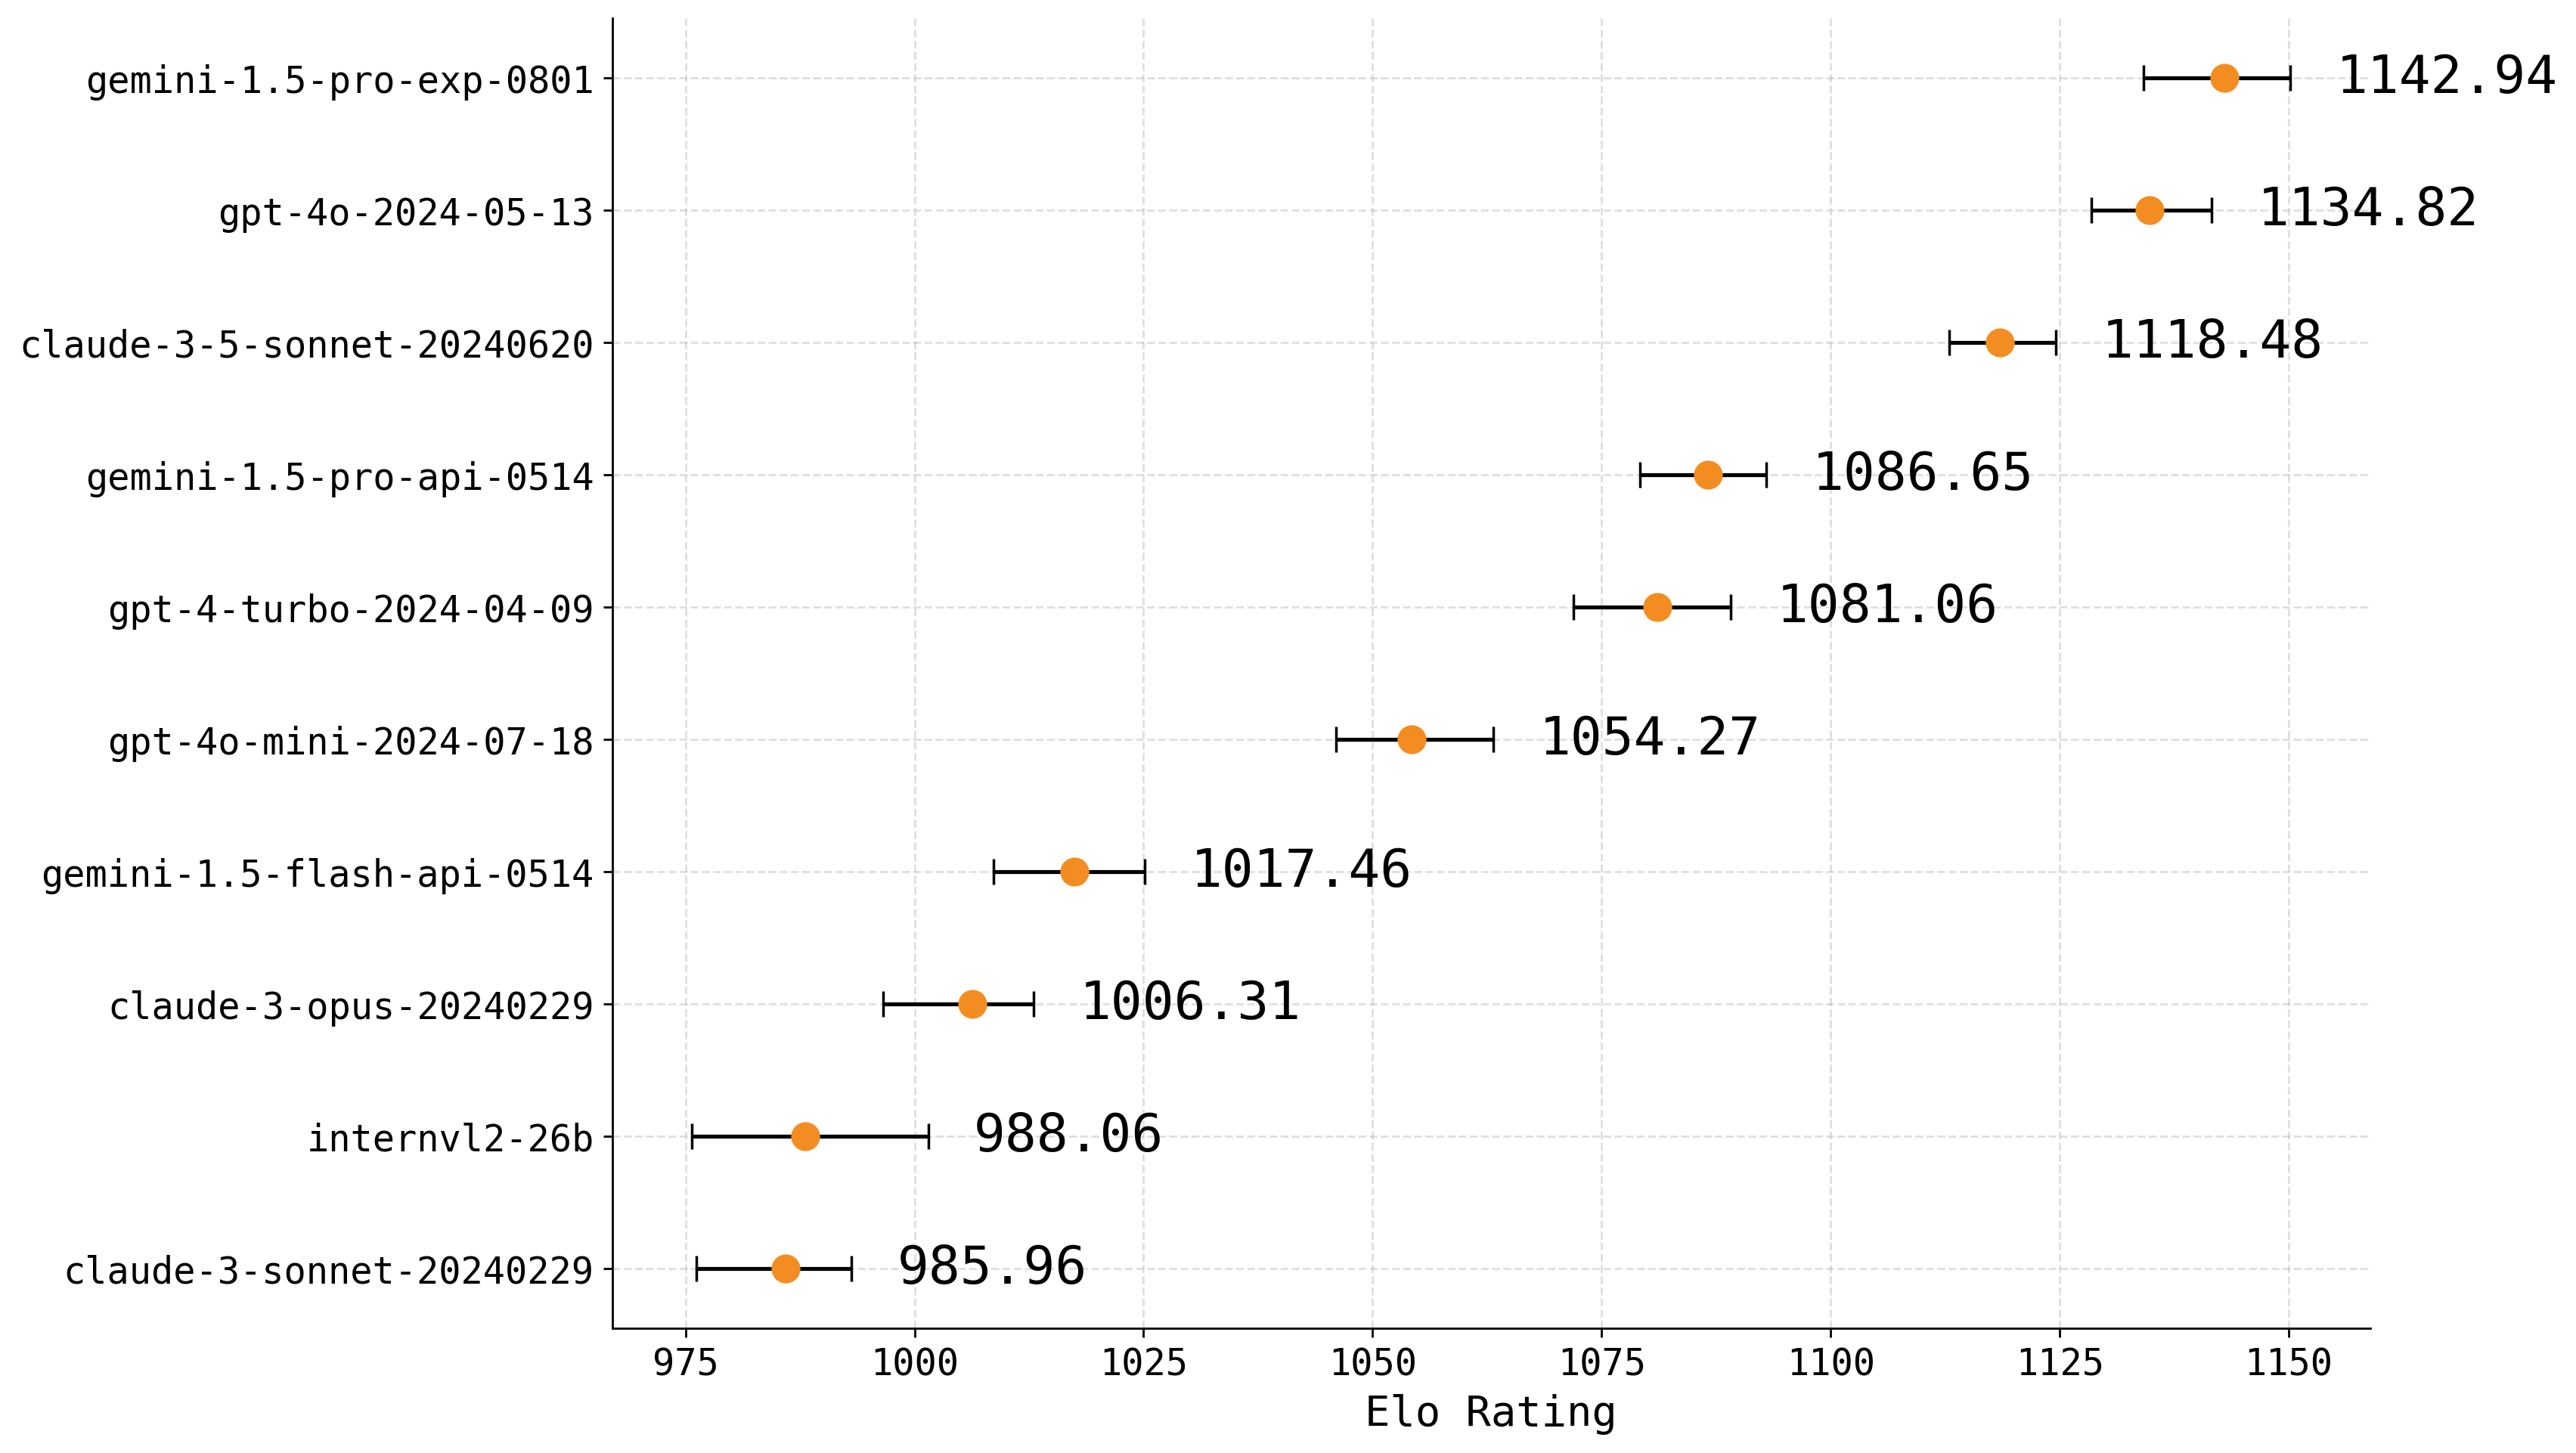

In [40]:
# plot the top 10 models.
compute_CIs.plot_elo_confidence_intervals(ci_df.head(10))

#### Identify the pool of influential points for auditing Top-1 Robustness

In [41]:
import math
k = 1
alphaN = math.floor(0.02 * len(df))
print(alphaN)
chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, top1_mis_indices = isRankingRobust(k, alphaN, X, y,  weighted = True)

596


bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

bootstrap: 100%|██████████| 100/100 [00:04<00:00, 20.51it/s]


                                   2.5%       Median        97.5%
model_a                                                          
gpt-4o-2024-05-13           1135.158678  1142.197874  1149.667935
gemini-1.5-pro-exp-0801     1125.199457  1132.853073  1140.917706
claude-3-5-sonnet-20240620  1112.622747  1118.055191  1125.204626
gemini-1.5-pro-api-0514     1079.344319  1086.098747  1093.280836
gpt-4-turbo-2024-04-09      1074.447932  1081.237733  1090.597020
fraction of preferences dropped: 0.0041877449830815105


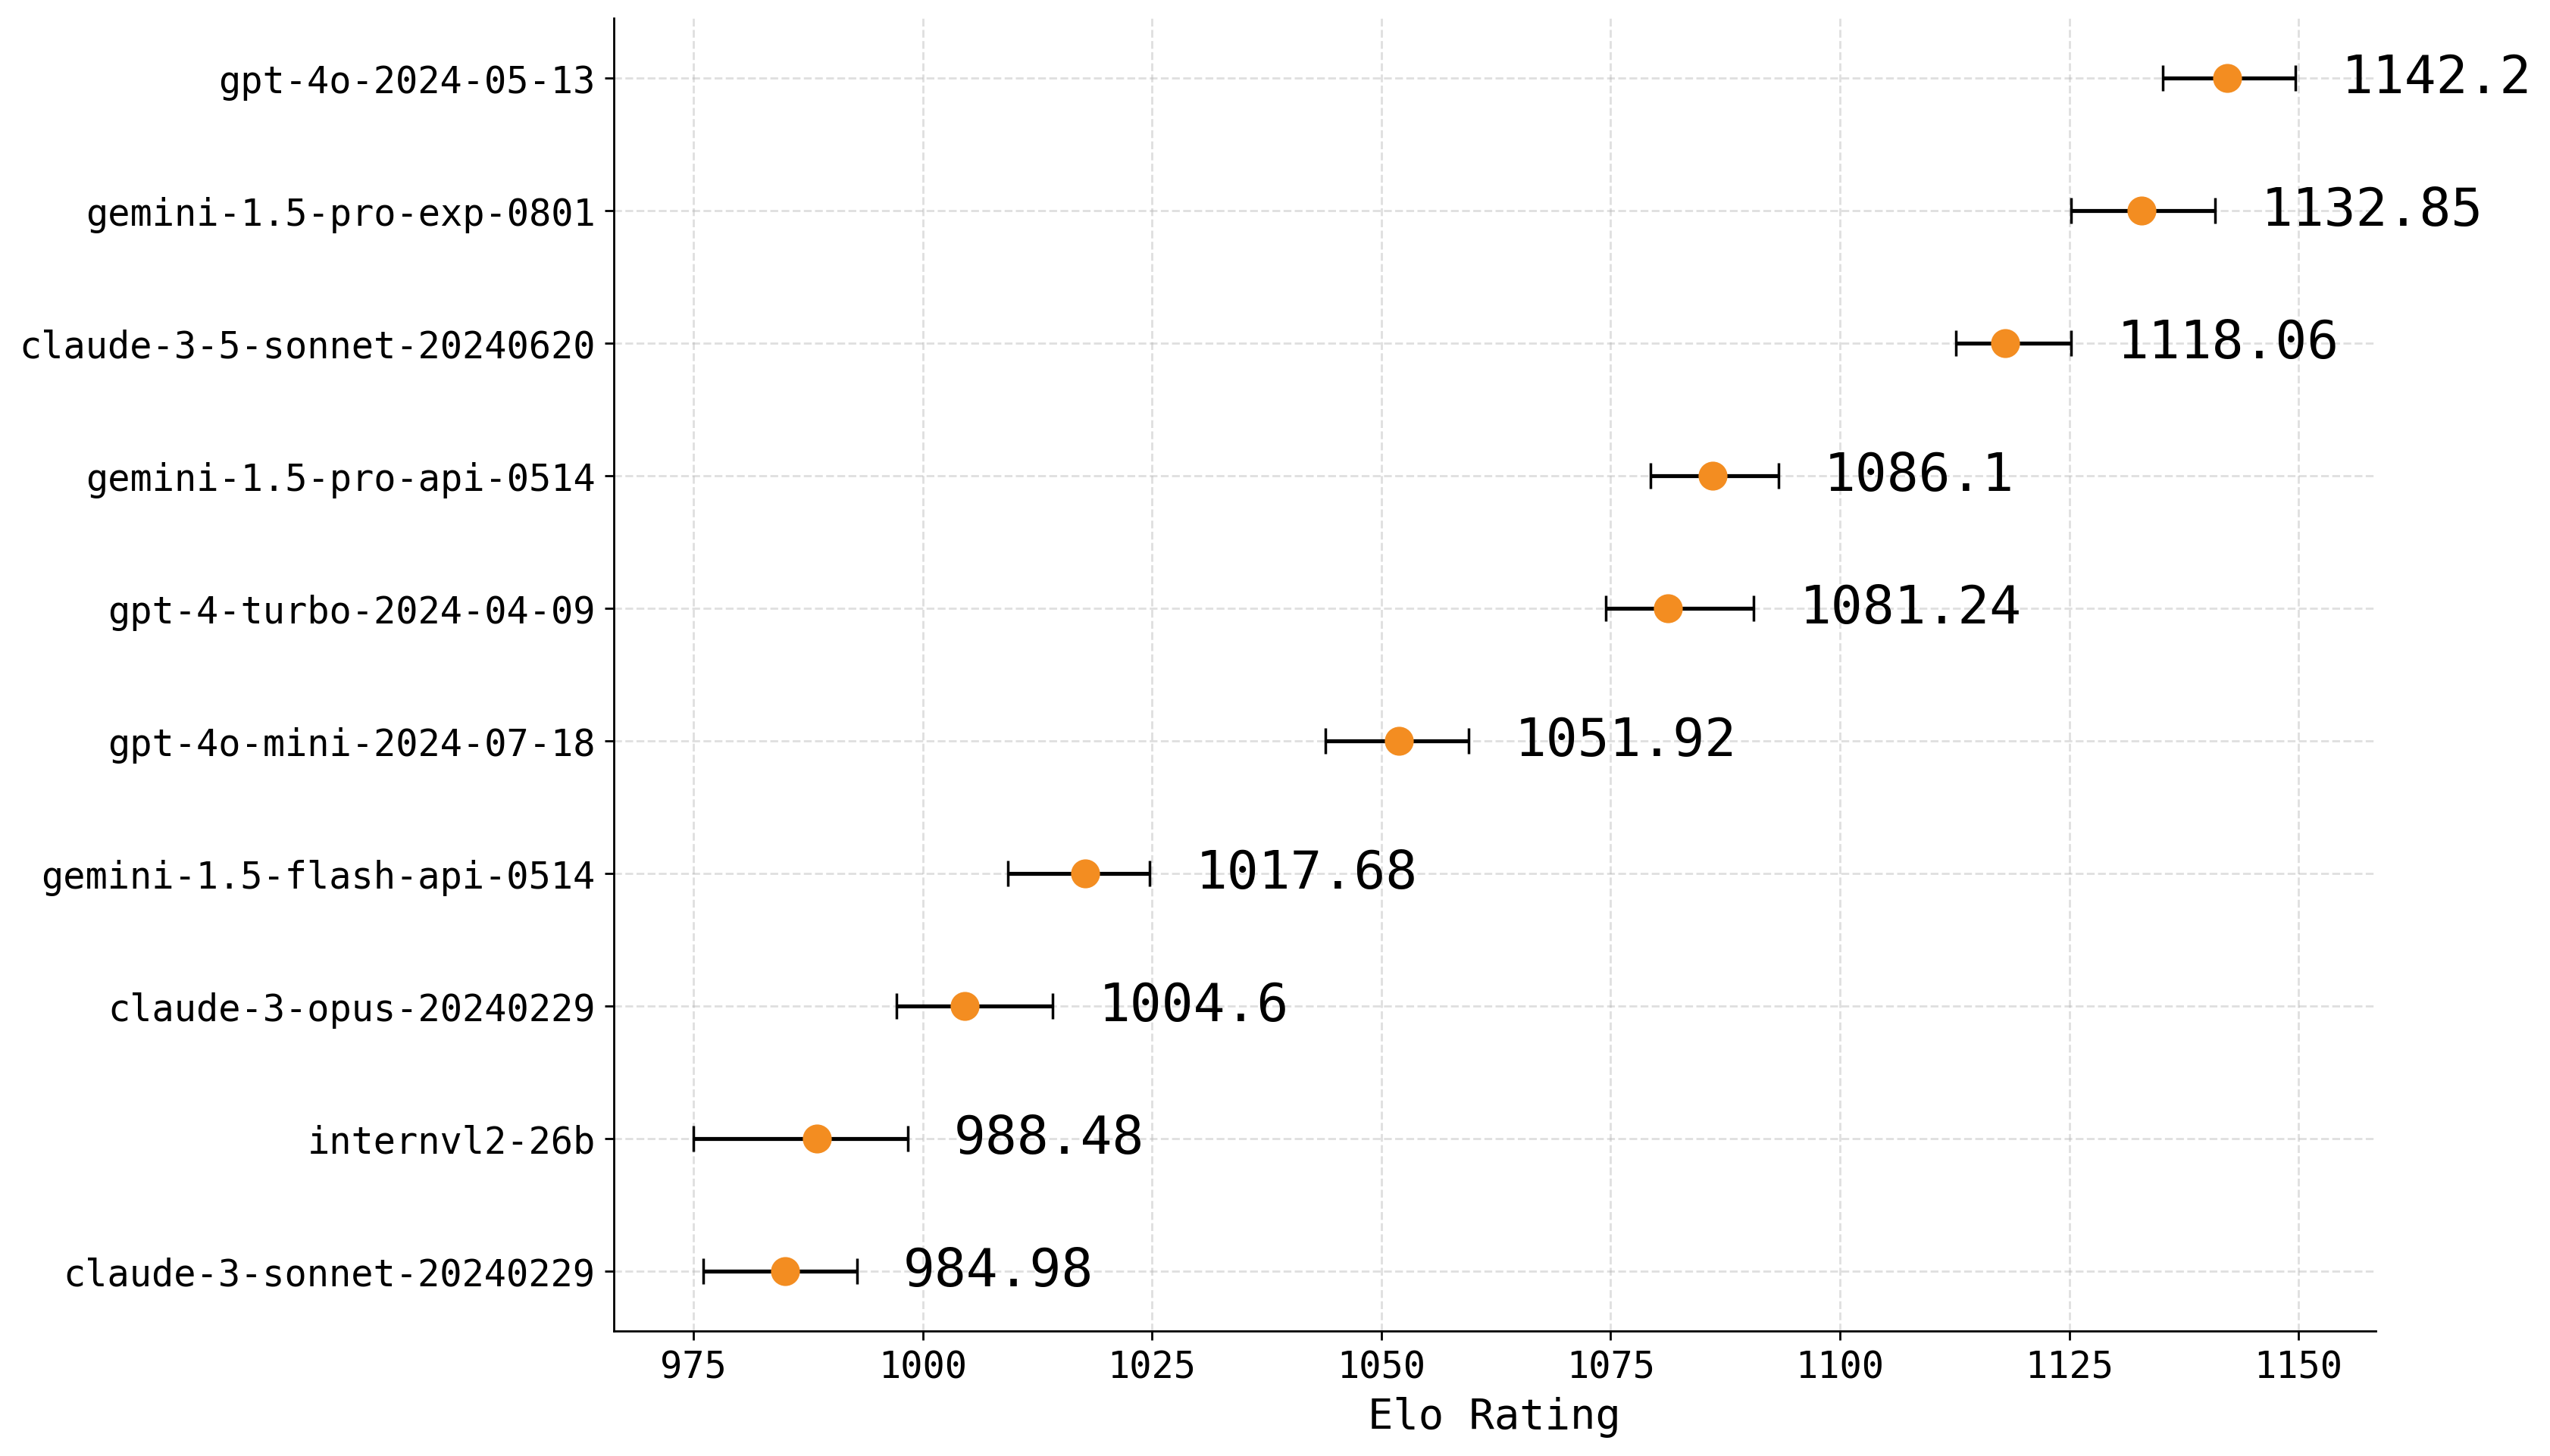

In [47]:
# remove top_1_mis from df
num_dropped = 125
df_dropped = df.drop(top1_mis_indices[:num_dropped]).reset_index(drop=True)

len(df), len(df_dropped)

BOOTSTRAP_ROUNDS = 100
bootstrap_top1_mis_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
print(ci_df_dropped.head())

print(f'fraction of preferences dropped: {num_dropped / len(df)}')
compute_CIs.plot_elo_confidence_intervals(ci_df_dropped.head(10), title=f"Top 10 Elo Ratings Upon Removing {num_dropped} out of {len(df)} of Preferences")


Remove the dropped subset.

In [33]:
df_dropped = df.drop(top_5_mis).reset_index(drop=True)

len(df), len(df_dropped)

(29849, 29703)

In [34]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:05<00:00, 18.10it/s]


In [35]:
bootstrap_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_dropped.quantile(0.025)
ci_upper = bootstrap_dropped.quantile(0.975)
ci_med = bootstrap_dropped.median()
dropped_ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
dropped_ci_df

,2.5%,Median,97.5%
model_a,,,
gemini-1.5-pro-exp-0801,1137.571629,1145.849689,1153.365936
gpt-4o-2024-05-13,1128.814298,1135.314143,1142.359928
claude-3-5-sonnet-20240620,1112.737178,1118.982692,1125.868179
gemini-1.5-pro-api-0514,1079.293806,1086.960595,1093.393101
gpt-4-turbo-2024-04-09,1065.595832,1071.680360,1078.575031
gpt-4o-mini-2024-07-18,1055.563730,1062.950437,1069.708725
gemini-1.5-flash-api-0514,1009.482467,1018.176500,1027.175299
claude-3-opus-20240229,998.537230,1005.635382,1012.709323
internvl2-26b,978.262777,989.477707,1002.792262


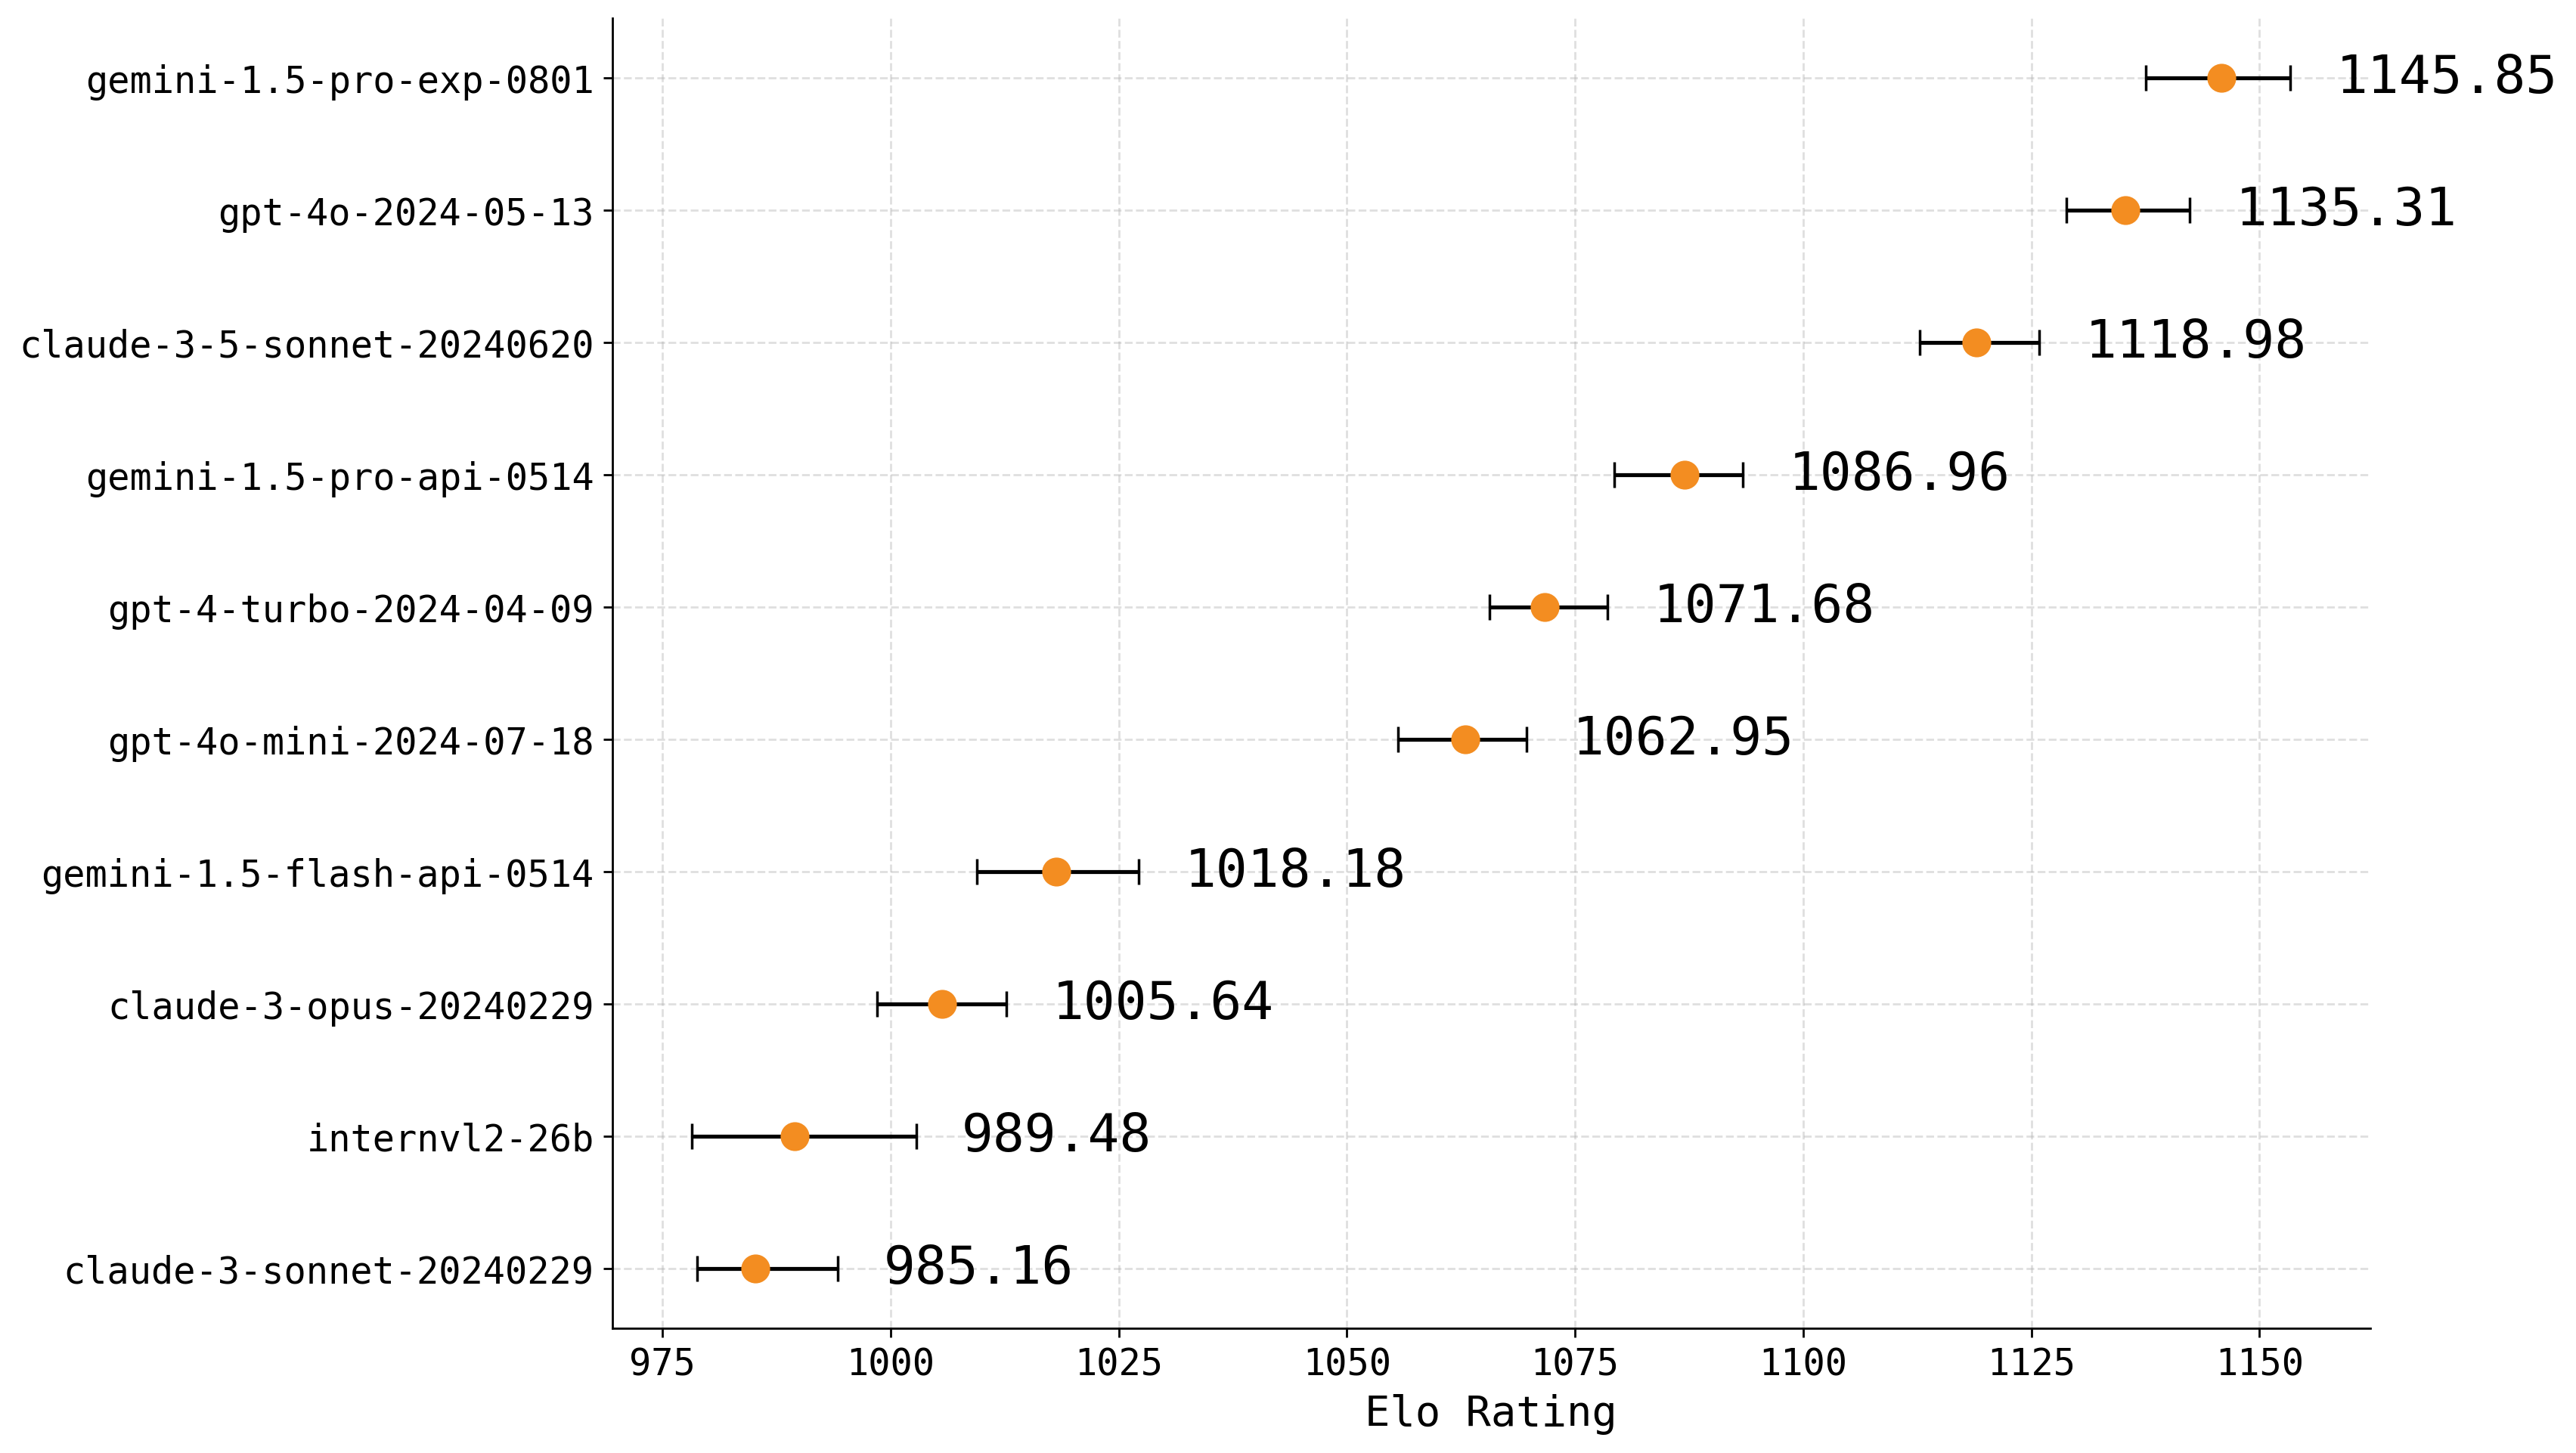

In [36]:
compute_CIs.plot_elo_confidence_intervals(dropped_ci_df.head(10), title="Top 10 Elo Ratings (Upon Removing 29/57477 (0.05%) of Preferences)")

In [ ]:
# find the two models that changed ranking.
## Count number of games between the first- and second-place models played in total.
is_gemini_gpt4o = (
    (df['model_a'].str.contains('gemini-1.5-pro-exp-0801') & df['model_b'].str.contains('gpt-4o-2024-05-13')) |
    (df['model_a'].str.contains('gpt-4o-2024-05-13') & df['model_b'].str.contains('gemini-1.5-pro-exp-0801'))
)

num_gemini_gpt4o = df[is_gemini_gpt4o].shape[0]
print("Number of games between claude haiku and claude sonnet: ", num_gemini_gpt4o)

Number of games between claude haiku and claude sonnet:  455


In [ ]:
# model pairs
df['model_pair'] = df.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)
df['model_pair']

# Compute average games per model pair across the arena.
pair_counts = df['model_pair'].value_counts()
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 242.6747967479675


In [ ]:
df['winner_model_b'] = ((df['winner_model_a'] == 0) & (df['winner_tie'] == 0)).astype(int)
df.head()

,images,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,num_turns,language,tstamp,conv_metadata,categories,winner_model_a,winner_tie,model_pair,winner_model_b
0,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,94f6f6508b6946db809cc700fbf57eb3,claude-3-opus-20240229,gpt-4o-2024-05-13,model_b,arena_user_WnxPidjDzH2jGCBPPDvbfm,"[[{'content': 'describe this cartoon', 'role':...","[[{'content': 'describe this cartoon', 'role':...",1,English,1.721366e+09,"{'context_a_tokens': 3, 'context_b_tokens': 3,...","{'captioning': True, 'creative_writing': False...",0,0,"(claude-3-opus-20240229, gpt-4o-2024-05-13)",1
1,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,e7ef1e9839b746699f066ad1f255ad75,gemini-1.5-pro-exp-0801,claude-3-5-sonnet-20240620,model_b,arena_user_eKUpfCPzV2vdxp5TKsnNxe,[[{'content': 'Generate a list of relevant que...,[[{'content': 'Generate a list of relevant que...,1,English,1.721725e+09,"{'context_a_tokens': 11, 'context_b_tokens': 1...","{'captioning': False, 'creative_writing': Fals...",0,0,"(claude-3-5-sonnet-20240620, gemini-1.5-pro-ex...",1
2,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,29a843b27c614391a6732e6c042fd5e0,gemini-1.5-flash-api-0514,claude-3-5-sonnet-20240620,model_b,arena_user_juLTzBXrDyBdSEunwWztg9,[[{'content': 'What bug died in my garden? Tho...,[[{'content': 'What bug died in my garden? Tho...,1,English,1.719587e+09,"{'context_a_tokens': 15, 'context_b_tokens': 1...","{'captioning': False, 'creative_writing': Fals...",0,0,"(claude-3-5-sonnet-20240620, gemini-1.5-flash-...",1
3,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,274643b7fe2545c5bf32c7d5931d1553,reka-core-20240501,reka-flash-preview-20240611,tie,arena_user_Vb4wt4yAppRPwcAqukiU2N,[[{'content': 'Was versucht dieses Bild auszud...,[[{'content': 'Was versucht dieses Bild auszud...,1,German,1.719740e+09,"{'context_a_tokens': 45, 'context_b_tokens': 4...","{'captioning': False, 'creative_writing': Fals...",0,1,"(reka-core-20240501, reka-flash-preview-20240611)",0
4,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,6ff0af95d14b411ca63f7ac5a281a9a1,claude-3-sonnet-20240229,llava-v1.6-34b,model_a,arena_user_FerRcceDpgBNiJyEmZCZWF,[[{'content': 'What can you say about this cha...,[[{'content': 'What can you say about this cha...,1,English,1.719235e+09,"{'context_a_tokens': 8, 'context_b_tokens': 8,...","{'captioning': False, 'creative_writing': Fals...",1,0,"(claude-3-sonnet-20240229, llava-v1.6-34b)",0


In [ ]:
# Find the win margin between 'claude-3-5-haiku-20241022' and 'claude-3-5-sonnet-20241022'
# that is, find all games that are between the two models.
dfFlippedRanking = df[is_gemini_gpt4o]
## Count number of games between that 'claude-3-5-haiku-20241022' won.
gemini_wins = (
    (dfFlippedRanking['model_a'].str.contains('gemini-1.5-pro-exp-0801') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('gemini-1.5-pro-exp-0801') & dfFlippedRanking['winner_model_b'] == 1)
)
num_gemini_wins = dfFlippedRanking[gemini_wins].shape[0]
 # 0.5373134328358209

gpt4o_wins = (
    (dfFlippedRanking['model_a'].str.contains('gpt-4o-2024-05-13') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('gpt-4o-2024-05-13') & dfFlippedRanking['winner_model_b'] == 1)
)

num_gemini_wins = dfFlippedRanking[gemini_wins].shape[0]
num_gpt4o_wins = dfFlippedRanking[gpt4o_wins].shape[0]

print("Proportion of games that gpt4o won: ", num_gpt4o_wins / (num_gemini_wins + num_gpt4o_wins))


Proportion of games that gpt4o won:  0.5060240963855421


In [ ]:
num_haiku_wins, num_sonnet_wins

(26, 60)